# Embeddings εκτός ImageNet

Σε αυτό το notebook παίρνουμε εικόνες εκτός ImageNet: angler fish (βατραχόψαρο), goblin shark (καρχαρίας καλικάντζαρος), και το Tesla Cybertruck. Τις περνάμε από ένα προεκπαιδευμένο `resnet18` και μελετάμε:

- τις **ενσωματώσεις (embeddings)** των εικόνων (διάνυσμα 512 διαστάσεων)
- τις **ενδο-κλασικές** και **μεταξύ-κλασικές** αποστάσεις
- απλές 2D προβολές (PCA) για να δούμε αν οι κλάσεις σχηματίζουν «συστάδες»

Με αυτόν τον τρόπο, εξετάζουμε την δυνατότητα του δικτύου Resnet18 (χωρίς περαιτέρο εκπαίδευση) παράγει σημασιολογικές ενσωματώσεις εικόνων.

Διαλέγουμε τις τρεις παραπάνω κατηγορίες, για να εξετάσουμε την δυνατότητα της resnet να παράγει σημασιολογικές ενσωματώσεις σε κατηγορίες και εικόνες πάνω στις οποίες **δεν έχει εκπαιδευτεί**.

```
Κωνσταντίνος Καραμανής: constantine@utexas.edu
http://users.ece.utexas.edu/~cmcaram/
The University of Texas at Austin
Archimedes/Athena RC
```


## Φόρτωση μοντέλου + preprocessing + εξαγωγή embeddings

- Κατεβάζουμε/φορτώνουμε το προεκπαιδευμένο `resnet18` (ImageNet weights).
- Χρησιμοποιούμε τα **στατιστικά του ImageNet** (mean/std) μέσω `weights.transforms()`.
- Αφαιρούμε το τελευταίο layer (`fc`) ώστε το δίκτυο να επιστρέφει **512-διάστατα embeddings**.
- Για κάθε κλάση (φάκελο) υπολογίζουμε embeddings για όλες τις εικόνες.

In [1]:
import os
from pathlib import Path

import torch
from torchvision.models import ResNet18_Weights, resnet18
from PIL import Image

import matplotlib.pyplot as plt



### Ετοιμάζουμε το Μοντέλο (Resnet18)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet18_Weights.DEFAULT
preprocess = weights.transforms()  # includes ImageNet mean/std normalization

model = resnet18(weights=weights)
model.fc = torch.nn.Identity()  # outputs 512-dim embedding
model.eval().to(device)



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
import os
import zipfile
import urllib.request
from pathlib import Path

# --- Download and extract images if not present ---
zip_url = "https://drive.google.com/uc?export=download&id=1kXbKCmstZXGAt_Q7zduKKRGAe01lqMTt"
zip_path = "embedding_pics.zip"
extract_dir = "embedding_pics"

if not os.path.exists(extract_dir):
    print("Downloading sample images zip...")
    # Download file
    urllib.request.urlretrieve(zip_url, zip_path)
    # Extract
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
    print(f"Done. Images extracted to '{extract_dir}/'")
    os.remove(zip_path)

# Adjust base path for nested extraction
base = Path(extract_dir) / extract_dir
class_names = ["angler", "goblin_shark", "cyber_truck"]
class_dirs = {name: base / name for name in class_names}

### Οι εικόνες μας

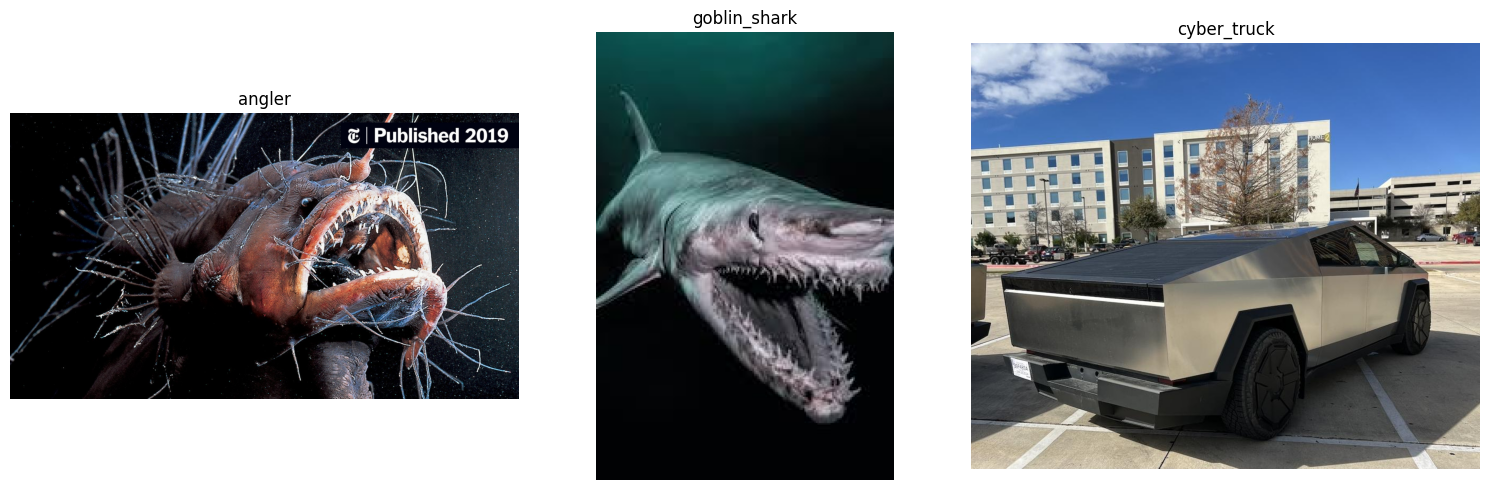

In [13]:
# display some of the images
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, len(class_names), figsize=(15, 5))

for ax, name in zip(axes, class_names):
    img_paths = list(class_dirs[name].iterdir())
    # Show the first image in each class folder
    if img_paths:
        img = Image.open(img_paths[0])
        ax.imshow(img)
        ax.set_title(name)
        ax.axis("off")
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

### Υπολογίζουμε τις Ενσωματώσεις

In [14]:
for name, d in class_dirs.items():
    assert d.exists(), f"Missing folder: {d}"

def list_image_paths(folder: Path):
    exts = {".jpg", ".jpeg", ".png", ".webp", ".avif"}
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts])

def embed_image_paths(paths, batch_size: int = 32):
    """Returns (embeddings, preprocessed_images, ok_paths, skipped)."""
    tensors = []
    ok_paths = []
    skipped = []

    for p in paths:
        try:
            img = Image.open(p).convert("RGB")
            t = preprocess(img)
            tensors.append(t)
            ok_paths.append(p)
        except Exception as e:
            skipped.append((p, repr(e)))

    if len(tensors) == 0:
        raise RuntimeError(
            "No images could be opened. If your files are .avif, you may need `pip install pillow-avif-plugin`."
        )

    x_all = torch.stack(tensors, dim=0)

    embs = []
    with torch.no_grad():
        for i in range(0, x_all.shape[0], batch_size):
            x = x_all[i : i + batch_size].to(device)
            e = model(x).detach().cpu()
            embs.append(e)

    embs = torch.cat(embs, dim=0)
    return embs, x_all, ok_paths, skipped

# --- compute embeddings for each class ---
embs = {}
embs_n = {}
pre_imgs = {}
paths_ok = {}
skipped = {}

for name in class_names:
    paths = list_image_paths(class_dirs[name])
    E, X_pre, ok, sk = embed_image_paths(paths)
    embs[name] = E
    embs_n[name] = torch.nn.functional.normalize(E, p=2, dim=1)
    pre_imgs[name] = X_pre
    paths_ok[name] = ok
    skipped[name] = sk

print(f"Device: {device}")
for name in class_names:
    print(f"{name}: {len(paths_ok[name])} embedded, {len(skipped[name])} skipped")

for name in class_names:
    if skipped[name]:
        print(f"\nSkipped {name} files:")
        for p, err in skipped[name]:
            print(" -", p.name, err)

A, B, C = embs["angler"], embs["goblin_shark"], embs["cyber_truck"]
A_n, B_n, C_n = embs_n["angler"], embs_n["goblin_shark"], embs_n["cyber_truck"]

Device: cpu
angler: 10 embedded, 0 skipped
goblin_shark: 10 embedded, 0 skipped
cyber_truck: 10 embedded, 0 skipped


## Αποστάσεις στο embedding space

Μετά την εξαγωγή embeddings, υπολογίζουμε:

- **intra-class L2** αποστάσεις (μέσα στην ίδια κλάση)
- **inter-class L2** αποστάσεις (ανάμεσα σε διαφορετικές κλάσεις)

και τυπώνουμε συνοπτικά στατιστικά (mean/median/min/max), καθώς και την απόσταση ανάμεσα στα **μέσα embeddings** (class means).

In [15]:
def upper_triangle_without_diag(square_dist_mat: torch.Tensor) -> torch.Tensor:
    # Returns d(i,j) for i<j as a 1D tensor
    n = square_dist_mat.shape[0]
    idx = torch.triu_indices(n, n, offset=1)
    return square_dist_mat[idx[0], idx[1]]


def summarize(name: str, d: torch.Tensor):
    return {
        "name": name,
        "n": int(d.numel()),
        "mean": float(d.mean()),
        "median": float(d.median()),
        "min": float(d.min()),
        "max": float(d.max()),
    }

# --- L2 distances on raw embeddings ---
intra_l2 = {name: upper_triangle_without_diag(torch.cdist(embs[name], embs[name], p=2)) for name in class_names}

inter_l2 = {}
for i in range(len(class_names)):
    for j in range(i + 1, len(class_names)):
        a, b = class_names[i], class_names[j]
        inter_l2[(a, b)] = torch.cdist(embs[a], embs[b], p=2).flatten()

print("L2 distance summaries:")
for name in class_names:
    print(summarize(f"intra_{name}", intra_l2[name]))
for (a, b), d in inter_l2.items():
    print(summarize(f"inter_{a}_vs_{b}", d))

# "two points" version: class-mean embeddings (pairwise)
means = {name: embs[name].mean(dim=0) for name in class_names}
print("\nL2 distance between class-mean embeddings:")
for i in range(len(class_names)):
    for j in range(i + 1, len(class_names)):
        a, b = class_names[i], class_names[j]
        mean_l2 = torch.linalg.norm(means[a] - means[b], ord=2).item()
        print(f"{a} vs {b}: {mean_l2:.4f}")

mean_intra = float(torch.cat([intra_l2[n] for n in class_names]).mean())
mean_inter = float(torch.cat([inter_l2[k] for k in inter_l2]).mean())
print("\nCheck (mean intra vs mean inter over all pairs):")
print("mean(intra) =", mean_intra)
print("mean(inter) =", mean_inter)


L2 distance summaries:
{'name': 'intra_angler', 'n': 45, 'mean': 24.189773559570312, 'median': 24.40983009338379, 'min': 15.6871919631958, 'max': 30.333820343017578}
{'name': 'intra_goblin_shark', 'n': 45, 'mean': 23.848922729492188, 'median': 23.26898765563965, 'min': 17.550765991210938, 'max': 29.684614181518555}
{'name': 'intra_cyber_truck', 'n': 45, 'mean': 18.424165725708008, 'median': 18.31866455078125, 'min': 14.961772918701172, 'max': 23.18240737915039}
{'name': 'inter_angler_vs_goblin_shark', 'n': 100, 'mean': 26.887338638305664, 'median': 26.982389450073242, 'min': 21.650407791137695, 'max': 31.441312789916992}
{'name': 'inter_angler_vs_cyber_truck', 'n': 100, 'mean': 27.217912673950195, 'median': 26.726537704467773, 'min': 23.277376174926758, 'max': 33.68636703491211}
{'name': 'inter_goblin_shark_vs_cyber_truck', 'n': 100, 'mean': 28.478654861450195, 'median': 28.610429763793945, 'min': 24.948869705200195, 'max': 32.20009994506836}

L2 distance between class-mean embeddings:

## Οπτικοποίηση κατανομών αποστάσεων

Εδώ κάνουμε histogram των αποστάσεων:

- intra-class ανά κλάση
- inter-class ανά ζεύγος κλάσεων

Αν το embedding «δουλεύει», περιμένουμε οι inter-class αποστάσεις να είναι (κατά μέσο όρο) **μεγαλύτερες** από τις intra-class.

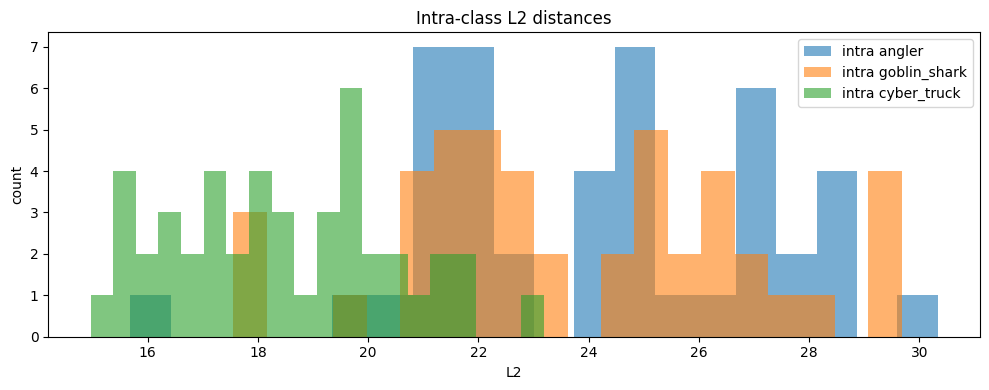

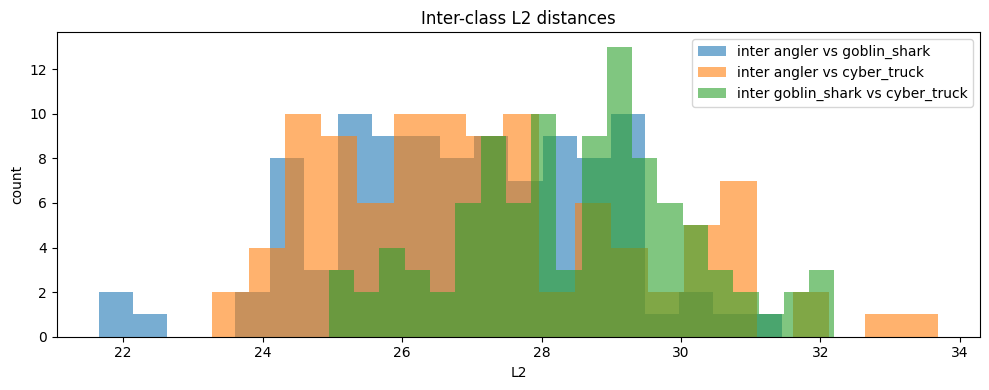

In [7]:
# Visualize distance distributions (3 classes)

# Intra-class (one histogram per class)
plt.figure(figsize=(10, 4))
for name in class_names:
    plt.hist(intra_l2[name].numpy(), bins=20, alpha=0.6, label=f"intra {name}")
plt.title("Intra-class L2 distances")
plt.xlabel("L2")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

# Inter-class (one histogram per class-pair)
plt.figure(figsize=(10, 4))
for (a, b), d in inter_l2.items():
    plt.hist(d.numpy(), bins=20, alpha=0.6, label=f"inter {a} vs {b}")
plt.title("Inter-class L2 distances")
plt.xlabel("L2")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()


## Ποσοτική αξιολόγηση με αποστάσεις (AUC-like)

Υπολογίζουμε αποστάσεις:

- **intra-class**: αποστάσεις ανάμεσα σε ζεύγη εικόνων της ίδιας κλάσης
- **inter-class**: αποστάσεις ανάμεσα σε ζεύγη εικόνων από διαφορετικές κλάσεις

Και μετράμε ένα **AUC-like** σκορ: την πιθανότητα μια τυχαία inter απόσταση να είναι μεγαλύτερη από μια τυχαία intra απόσταση.

Επίσης κοιτάμε **cosine distance** (συχνά πιο κατάλληλο για embeddings) και δίνουμε και pairwise σκορ ανά ζεύγος κλάσεων.

In [8]:
# Stronger quantitative check (3 classes): how often is inter > intra?

all_intra_l2 = torch.cat([intra_l2[n] for n in class_names], dim=0)
all_inter_l2 = torch.cat([inter_l2[k] for k in inter_l2], dim=0)

# AUC-like score for distance as a classifier: 1 means perfect separation, 0.5 means random
# AUC = P(inter > intra) + 0.5 * P(inter == intra)
cmp = all_inter_l2[:, None] - all_intra_l2[None, :]
auc_l2 = (cmp > 0).float().mean().item() + 0.5 * (cmp == 0).float().mean().item()
print("AUC-like score using L2 distance (all inter vs all intra):", auc_l2)
print("Fraction of inter distances above median intra:", float((all_inter_l2 > all_intra_l2.median()).float().mean()))

# Cosine distance (often better for embeddings)
intra_cos = {name: upper_triangle_without_diag(1 - (embs_n[name] @ embs_n[name].T)) for name in class_names}

inter_cos = {}
for i in range(len(class_names)):
    for j in range(i + 1, len(class_names)):
        a, b = class_names[i], class_names[j]
        inter_cos[(a, b)] = (1 - (embs_n[a] @ embs_n[b].T)).flatten()

all_intra_cos = torch.cat([intra_cos[n] for n in class_names], dim=0)
all_inter_cos = torch.cat([inter_cos[k] for k in inter_cos], dim=0)

cmp_cos = all_inter_cos[:, None] - all_intra_cos[None, :]
auc_cos = (cmp_cos > 0).float().mean().item() + 0.5 * (cmp_cos == 0).float().mean().item()
print("AUC-like score using cosine distance (all inter vs all intra):", auc_cos)

print("\nCosine distance summaries:")
for name in class_names:
    print(summarize(f"intra_{name}_cos", intra_cos[name]))
for (a, b), d in inter_cos.items():
    print(summarize(f"inter_{a}_vs_{b}_cos", d))

print("\nPairwise AUC-like scores (cosine distance):")
for (a, b), d in inter_cos.items():
    pair_intra = torch.cat([intra_cos[a], intra_cos[b]], dim=0)
    cmp_pair = d[:, None] - pair_intra[None, :]
    auc_pair = (cmp_pair > 0).float().mean().item() + 0.5 * (cmp_pair == 0).float().mean().item()
    print(f"{a} vs {b}: {auc_pair:.3f}")


AUC-like score using L2 distance (all inter vs all intra): 0.8781975507736206
Fraction of inter distances above median intra: 0.996666669845581
AUC-like score using cosine distance (all inter vs all intra): 0.9542469382286072

Cosine distance summaries:
{'name': 'intra_angler_cos', 'n': 45, 'mean': 0.32542502880096436, 'median': 0.3418818712234497, 'min': 0.14555561542510986, 'max': 0.42878007888793945}
{'name': 'intra_goblin_shark_cos', 'n': 45, 'mean': 0.281019389629364, 'median': 0.2740126848220825, 'min': 0.14997410774230957, 'max': 0.4369008541107178}
{'name': 'intra_cyber_truck_cos', 'n': 45, 'mean': 0.2453317791223526, 'median': 0.24810278415679932, 'min': 0.15631866455078125, 'max': 0.3567918539047241}
{'name': 'inter_angler_vs_goblin_shark_cos', 'n': 100, 'mean': 0.3768315613269806, 'median': 0.3753611445426941, 'min': 0.25576311349868774, 'max': 0.49146175384521484}
{'name': 'inter_angler_vs_cyber_truck_cos', 'n': 100, 'mean': 0.46567845344543457, 'median': 0.4619501829147339

## Με μια μικρή ζαβολιά: Γραμμικός ταξινομητής πάνω στα embeddings

Εδώ εκπαιδεύουμε ένα `nn.Linear(512, K)` (logistic regression / linear classifier) **πάνω στα σταθερά embeddings**.

- Αυτό είναι επιβλεπόμενο (supervised, δηλαδή, χρησιμοποιεί labels), άρα μπορεί να «τονίσει» τον διαχωρισμό.


In [17]:
import torch.nn as nn

class LogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

In [20]:
# "Cheating": train a linear classifier on fixed embeddings (3 classes)
torch.manual_seed(0)

K = 3

# Use cosine-normalized embeddings (often works better)
Xs = []
ys = []
counts = []
for k, name in enumerate(class_names):
    Xk = embs_n[name]
    Xs.append(Xk)
    ys.append(torch.full((Xk.shape[0],), k, dtype=torch.long))
    counts.append(Xk.shape[0])

X = torch.cat(Xs, dim=0)  # (N, 512)
y = torch.cat(ys, dim=0)  # (N,)

log_reg_model = LogisticRegression(X.shape[1], K).to(device) # Instantiate the custom LogisticRegression model
optimizer = torch.optim.AdamW(log_reg_model.parameters(), lr=0.05, weight_decay=1e-3)

X_dev = X.to(device)
y_dev = y.to(device)

for step in range(1200):
    logits = log_reg_model(X_dev)
    loss = torch.nn.functional.cross_entropy(logits, y_dev)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    logits = log_reg_model(X_dev).detach().cpu()
    pred = logits.argmax(dim=1)
    acc = (pred == y).float().mean().item()

print("Training accuracy:", acc)

# Confusion matrix (rows=true, cols=pred)
cm = torch.zeros((K, K), dtype=torch.int64)
for t, p in zip(y, pred):
    cm[t, p] += 1
print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)
print("Class order:", class_names)


Training accuracy: 1.0

Confusion matrix (rows=true, cols=pred):
tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])
Class order: ['angler', 'goblin_shark', 'cyber_truck']


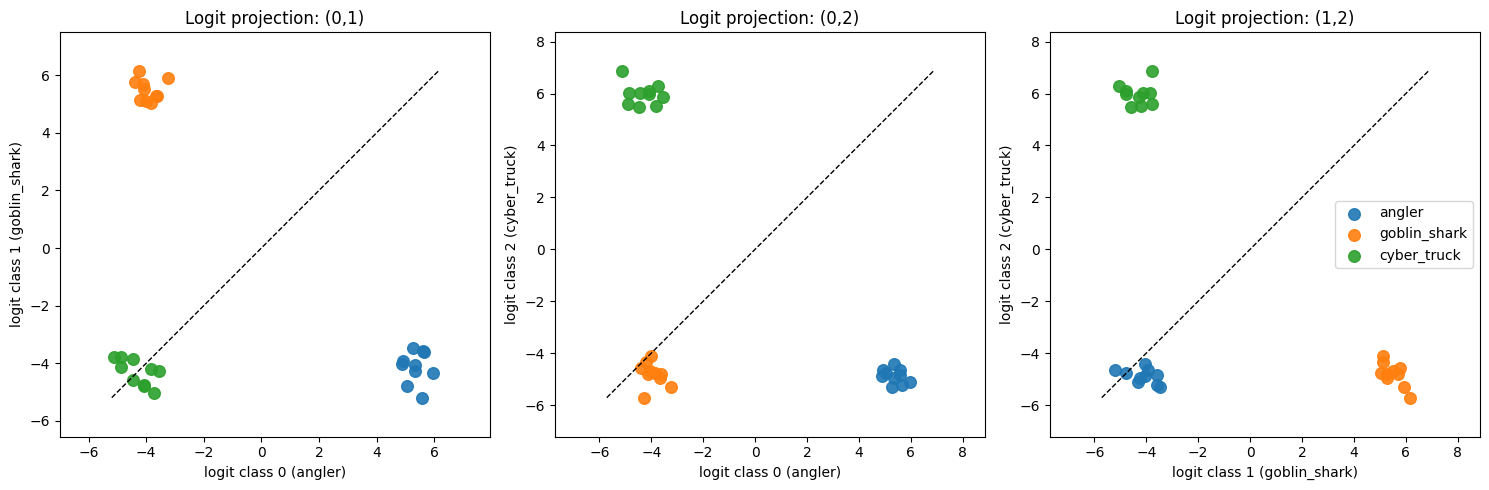

In [21]:
# Plot in logit projection space: all pairs (i,j)
pairs = [(i, j) for i in range(K) for j in range(i + 1, K)]

plt.figure(figsize=(5 * len(pairs), 5))

start = 0
idx_by_class = {}
for k, n in enumerate(counts):
    idx_by_class[k] = (start, start + n)
    start += n

for pi, (i, j) in enumerate(pairs, start=1):
    plt.subplot(1, len(pairs), pi)

    li = logits[:, i].numpy()
    lj = logits[:, j].numpy()

    for k, name in enumerate(class_names):
        s, e = idx_by_class[k]
        plt.scatter(li[s:e], lj[s:e], s=70, label=name, alpha=0.9)

    mn = min(li.min(), lj.min())
    mx = max(li.max(), lj.max())
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)

    plt.xlabel(f"logit class {i} ({class_names[i]})")
    plt.ylabel(f"logit class {j} ({class_names[j]})")
    plt.title(f"Logit projection: ({i},{j})")
    plt.axis("equal")

plt.legend()
plt.tight_layout()
plt.show()

## Μπρούμε να βγάλουμε συμπέρασμα;

Δεν μπορούμε! Με μόνο 30 σημεία σε 512 διαστάσεις, δεν είναι δύσκολο να βρεθεί ένα υπερεπίπεδο που χωρίζει καλά τα δεδομένα! Δομικάστε και εσείς, να δείτε πως οποιαδήποτε 30 σημεία σε 512 διαστάσεις και να διαλέξετε, πάντα μπορείτε να βρείτε έναν καλό γραμμικό ταξινομητή (με την λογιστική παλινδρόμηση).

Για να πειστούμε πως πράγματι είναι διαχωρίσιμες ή ομαδοποιημένες οι ενσωματώσεις, πρέπει είτε να χρησιμοποιήσουμε πολλά σημεία (όπως και κάναμε στο προηγούμενο notebook), ή να βρούμε μια προβολή των σημείων **που δεν είναι επιτηρούμενη/επιβλεπόμενη** (δεν χρησιμοποιεί τις ετικέτες των σημείων).

## PCA

Θα χρησιμοποιήσουμε την τεχνική που λέγεται **Principal Component Analysis (PCA)**. Δίνουμε τον κώδικα που υλοποιεί αυτήν την προβολή, χωρίς να μπούμε στις μαθηματικές λεπτομέρειες.

Διαισθητικά, το PCA βρίσκει τις κατευθύνσεις που "απλώνονται" πιο πολύ τα δεδομένα, δηλαδή τις πιο "σημαντικές" κατευθύνσεις. Επισημαίνουμε όμως, πως **δεν** χρησιμοποιεί γνώση των κατηγοριών (τα labels)!

### PCA στις «ακατέργαστες» εισόδους (pixel space)

Εδώ κάνουμε PCA **όχι** πάνω στα embeddings, αλλά πάνω στις ίδιες τις εικόνες αφού έχουν περάσει το **ίδιο ImageNet preprocessing** (resize/crop + κανονικοποίηση mean/std) και **πριν** μπουν στο ResNet.

Συνήθως στο pixel space η κύρια διακύμανση οφείλεται σε φωτεινότητα/φόντο/κάδρο κλπ, οπότε οι κλάσεις μπορεί να είναι «ανακατεμένες».

Αυτό ακριβώς παρατηρούμε εδώ.

Explained variance ratio on preprocessed pixels (PC1, PC2): [0.24976183474063873, 0.10095152258872986]


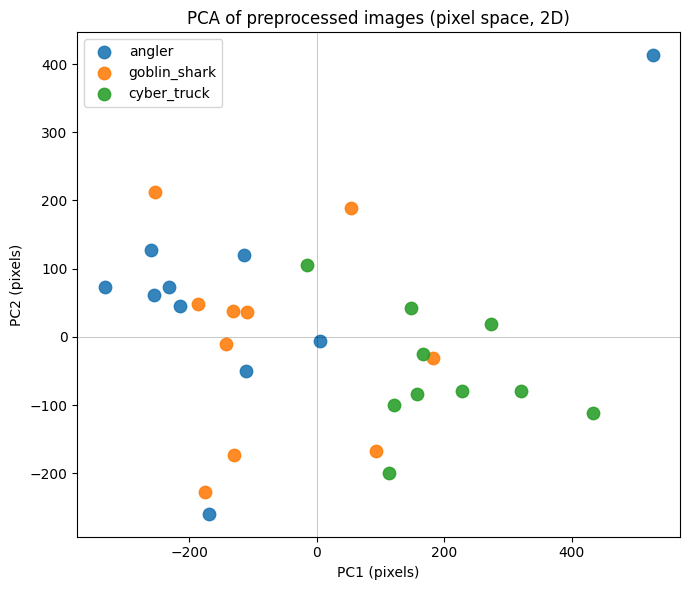

In [10]:
# PCA on "raw" inputs: the preprocessed image tensors (before ResNet)
# These are already resized/cropped and ImageNet-normalized via `weights.transforms()`.

Xs = []
ys = []
for k, name in enumerate(class_names):
    Xk = pre_imgs[name]  # (N,3,224,224)
    Xs.append(Xk.reshape(Xk.shape[0], -1))  # flatten to vectors
    ys.append(torch.full((Xk.shape[0],), k, dtype=torch.long))

X = torch.cat(Xs, dim=0).float()  # (N, 150528)
y = torch.cat(ys, dim=0)

# Center then SVD
Xc = X - X.mean(dim=0, keepdim=True)
U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)
Z = Xc @ Vh[:2].T  # (N,2)

# Explained variance ratio
var = (S**2) / (Xc.shape[0] - 1)
explained = (var / var.sum())[:2]
print("Explained variance ratio on preprocessed pixels (PC1, PC2):", explained.tolist())

Z_np = Z.numpy()

plt.figure(figsize=(7, 6))
for k, name in enumerate(class_names):
    mask = (y == k).numpy()
    plt.scatter(Z_np[mask, 0], Z_np[mask, 1], s=80, alpha=0.9, label=name)

plt.xlabel("PC1 (pixels)")
plt.ylabel("PC2 (pixels)")
plt.title("PCA of preprocessed images (pixel space, 2D)")
plt.legend()
plt.axhline(0, color="k", linewidth=0.5, alpha=0.3)
plt.axvline(0, color="k", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()


## PCA στα embeddings (512D → 2D)

Εδώ κάνουμε PCA πάνω στα **embeddings** που παράγει το `resnet18` (512 διαστάσεις). Θυμίζουμε πως η PCA είναι **μη-επιβλεπόμενη** (δεν χρησιμοποιεί labels), άρα αν δούμε διαχωρισμό/συστάδες ανά κλάση, είναι ένδειξη ότι το embedding space έχει «σημασιολογική» δομή -- δηλαδή πως υπάρχει ομαδοποίηση των διανυσματυκών ενσωματώσεων των σημείων.



Explained variance ratio (PC1, PC2): [0.23773187398910522, 0.10170075297355652]


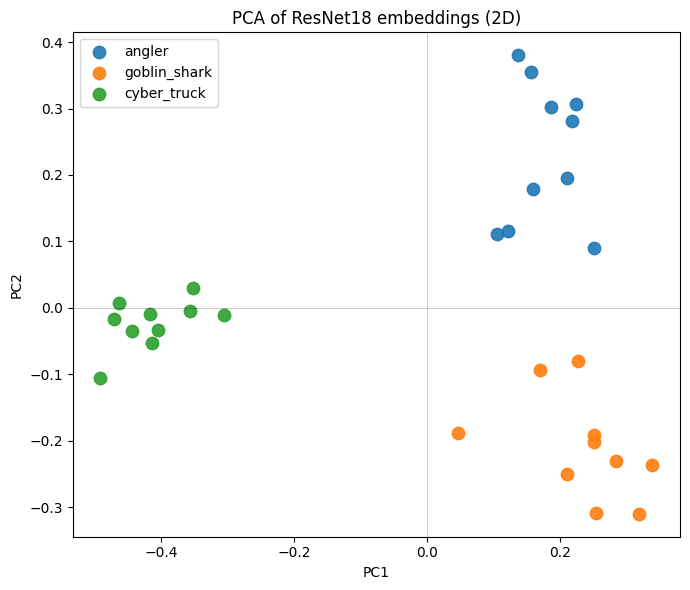

In [11]:
# PCA of embeddings to 2D (top 2 principal components)
# We'll use cosine-normalized embeddings (embs_n) stacked across classes.

Xs = []
ys = []
for k, name in enumerate(class_names):
    Xs.append(embs_n[name])
    ys.append(torch.full((embs_n[name].shape[0],), k, dtype=torch.long))

X = torch.cat(Xs, dim=0)  # (N, 512)
y = torch.cat(ys, dim=0)  # (N,)

# Center then SVD
Xc = X - X.mean(dim=0, keepdim=True)
U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)

Z = Xc @ Vh[:2].T  # (N,2)

# Explained variance ratio
var = (S**2) / (Xc.shape[0] - 1)
explained = (var / var.sum())[:2]
print("Explained variance ratio (PC1, PC2):", explained.tolist())

Z_np = Z.numpy()

plt.figure(figsize=(7, 6))
for k, name in enumerate(class_names):
    mask = (y == k).numpy()
    plt.scatter(Z_np[mask, 0], Z_np[mask, 1], s=80, alpha=0.9, label=name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of ResNet18 embeddings (2D)")
plt.legend()
plt.axhline(0, color="k", linewidth=0.5, alpha=0.3)
plt.axvline(0, color="k", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()
